# EDA- SUPERMARKET SALES

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Loading my Dataset

In [2]:
df=pd.read_csv(r"C:\Users\manas\Downloads\archive.zip")

# Basic info and clean-up

In [3]:
df.info()
df.describe()
df.isnull().sum()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

# Taking overview

In [13]:
print(df.head())
print(df.shape)
df.duplicated().sum()

    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428      A     Yangon        Member  Female   
1  226-31-3081      C  Naypyitaw        Normal  Female   
2  631-41-3108      A     Yangon        Normal    Male   
3  123-19-1176      A     Yangon        Member    Male   
4  373-73-7910      A     Yangon        Normal    Male   

             Product line  Unit price  Quantity   Tax 5%     Total       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

    Time      Payment    cogs  gross margin percentage  gross income  Rating  
0  13:08      Ewallet  522.83                 4.761905       26.1415     9.1  
1  10:

0

# For analysis converting date/time if they are in string

In [73]:
df['Date'] = pd.to_datetime(df['Date'])   
df['Month'] = df['Date'].dt.month_name()
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Time'] = pd.to_datetime(df['Time'], format='%I:%M %p')
df['Hour'] = df['Time'].dt.hour

In [15]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Month,Day
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08,Ewallet,522.83,4.761905,26.1415,9.1,January,Saturday
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29,Cash,76.40,4.761905,3.8200,9.6,March,Friday
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23,Credit card,324.31,4.761905,16.2155,7.4,March,Sunday
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33,Ewallet,465.76,4.761905,23.2880,8.4,January,Sunday
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37,Ewallet,604.17,4.761905,30.2085,5.3,February,Friday


# Now real analysis begins 

In [19]:
#  Group by month and calculate total sales
monthly_sales = df.groupby('Month')['Total'].sum()
print(monthly_sales)

Month
February     97219.374
January     116291.868
March       109455.507
Name: Total, dtype: float64


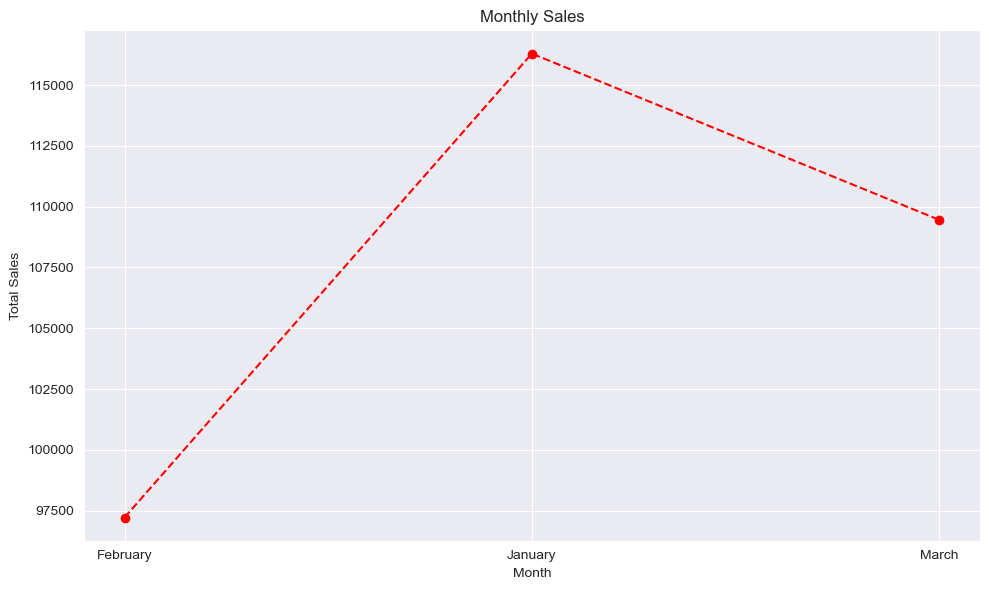

In [36]:
# Step 6: Plot the monthly sales
sns.set_style("darkgrid")
plt.figure(figsize=(10,6))
plt.plot(monthly_sales.index, monthly_sales.values,'o--r')
plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
daily_sales = df.groupby('DayOfWeek')['Total'].sum()
print(daily_sales)

DayOfWeek
Friday       43926.3405
Monday       37899.0780
Saturday     56120.8095
Sunday       44457.8925
Thursday     45349.2480
Tuesday      51482.2455
Wednesday    43731.1350
Name: Total, dtype: float64


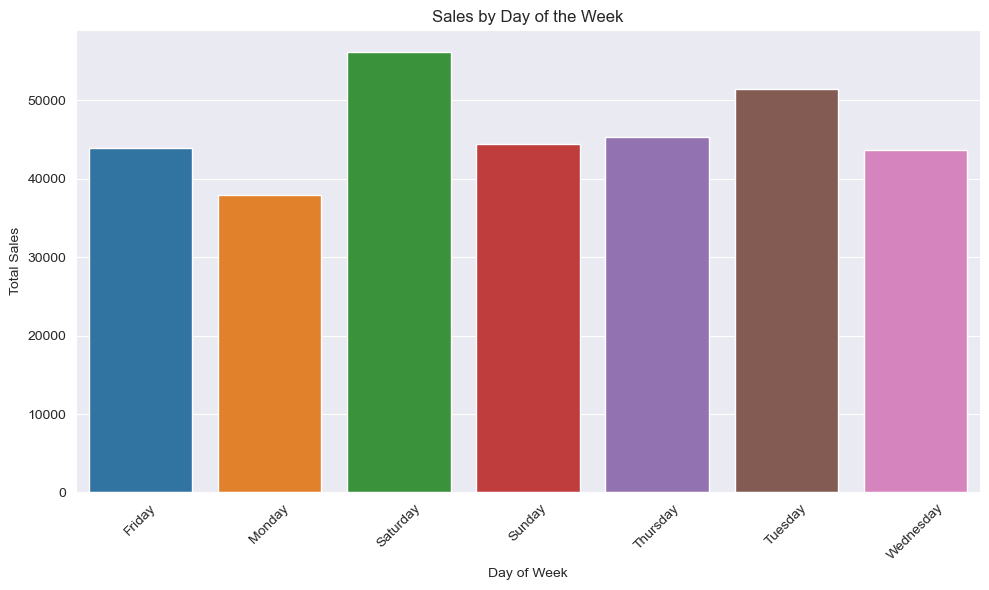

In [33]:
sns.set_style("darkgrid")
plt.figure(figsize=(10,6))
sns.barplot(x=daily_sales.index, y=daily_sales.values)

plt.title('Sales by Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Gender based Analysis


In [37]:
gender_sales = df.groupby('Gender')['Total'].sum()
print(gender_sales)


Gender
Female    167882.925
Male      155083.824
Name: Total, dtype: float64


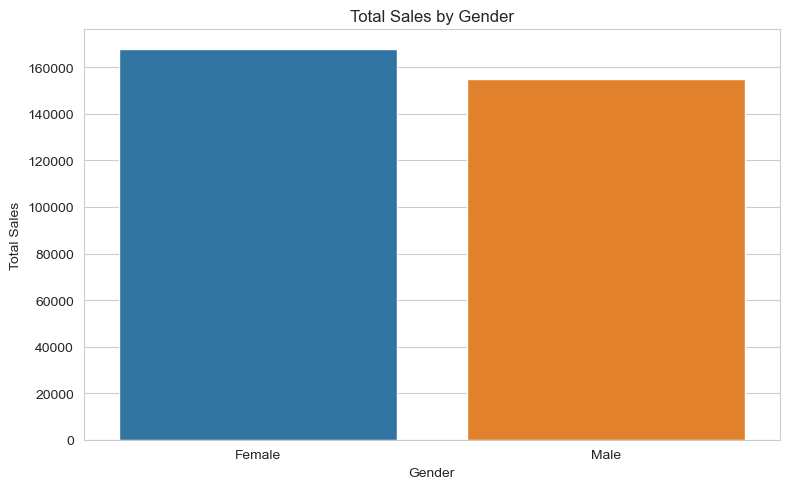

In [43]:
sns.set_style("whitegrid")

# Plot total sales by gender
plt.figure(figsize=(8,5))
sns.barplot(x=gender_sales.index, y=gender_sales.values)

plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()



In [39]:
gender_avg_sales = df.groupby('Gender')['Total'].mean()
print(gender_avg_sales)

Gender
Female    335.095659
Male      310.789226
Name: Total, dtype: float64


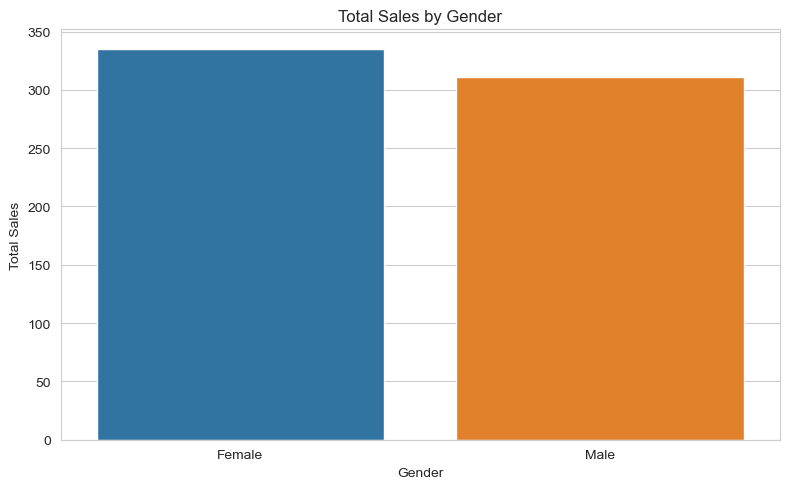

In [45]:
sns.set_style("whitegrid")

# Plot total sales by gender
plt.figure(figsize=(8,5))
sns.barplot(x=gender_avg_sales.index, y=gender_avg_sales.values)

plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

# Product Based Analysis


In [47]:
# Total quantity sold per product line
product_sales_qty = df.groupby('Product line')['Quantity'].sum().sort_values(ascending=False)

print(product_sales_qty)


Product line
Electronic accessories    971
Food and beverages        952
Sports and travel         920
Home and lifestyle        911
Fashion accessories       902
Health and beauty         854
Name: Quantity, dtype: int64


In [50]:
# Total revenue per product line
product_sales_total = df.groupby('Product line')['Total'].sum()

print(product_sales_total)


Product line
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Food and beverages        56144.8440
Health and beauty         49193.7390
Home and lifestyle        53861.9130
Sports and travel         55122.8265
Name: Total, dtype: float64


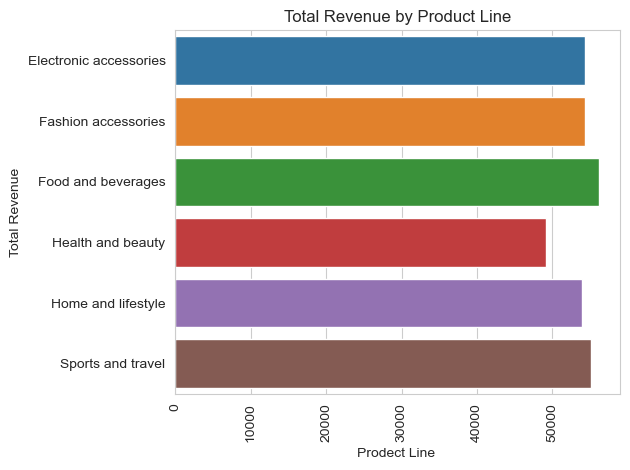

In [53]:
sns.barplot(y=product_sales_total.index , x=product_sales_total.values)
plt.title('Total Revenue by Product Line')
plt.xlabel('Prodect Line ')
plt.ylabel('Total Revenue')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [54]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Month,Day,DayOfWeek
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08,Ewallet,522.83,4.761905,26.1415,9.1,January,Saturday,Saturday
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29,Cash,76.40,4.761905,3.8200,9.6,March,Friday,Friday
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23,Credit card,324.31,4.761905,16.2155,7.4,March,Sunday,Sunday
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33,Ewallet,465.76,4.761905,23.2880,8.4,January,Sunday,Sunday
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37,Ewallet,604.17,4.761905,30.2085,5.3,February,Friday,Friday


In [55]:
branch_sales=df.groupby('Branch')['Total'].sum().sort_values(ascending=False)
print(branch_sales)                                

Branch
C    110568.7065
A    106200.3705
B    106197.6720
Name: Total, dtype: float64


In [56]:
correlation = df['Rating'].corr(df['Total'])
print(f"Correlation between Rating and Total Sales: {correlation:.2f}")

Correlation between Rating and Total Sales: -0.04


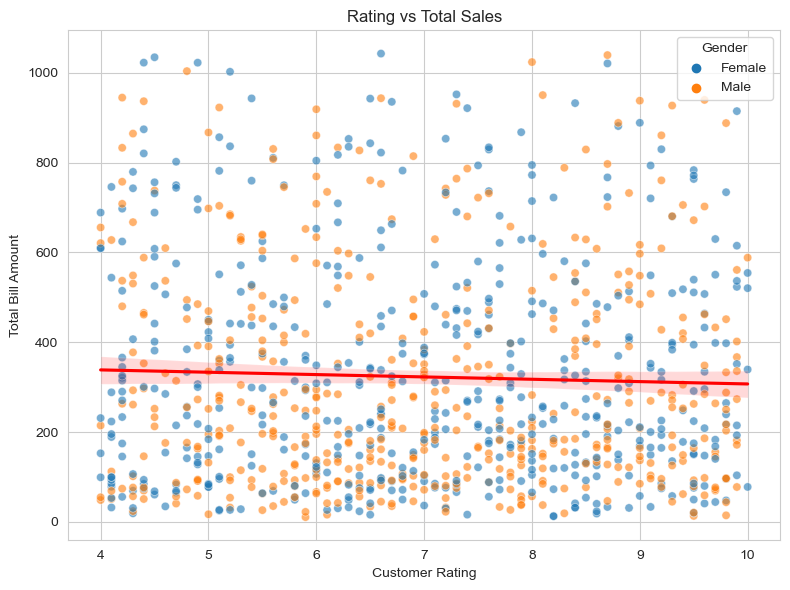

In [64]:
sns.set_style("whitegrid")
plt.figure(figsize=(8,6))

# Scatter plot
sns.scatterplot(data=df, x='Rating', y='Total', color='blue',hue="Gender", alpha=0.6)

# Trend/regression line
sns.regplot(data=df, x='Rating', y='Total', scatter=False, color='red')

plt.title('Rating vs Total Sales')
plt.xlabel('Customer Rating')
plt.ylabel('Total Bill Amount')
plt.tight_layout()
plt.show()


In [58]:
#Rating and Total sales are likely not related(-0.04)

In [61]:
branch_month_sales = df.groupby(['Branch', 'Month'])['Total'].sum().reset_index()
print(branch_month_sales)

  Branch     Month       Total
0      A  February  29860.1205
1      A   January  38681.1285
2      A     March  37659.1215
3      B  February  34424.2710
4      B   January  37176.0585
5      B     March  34597.3425
6      C  February  32934.9825
7      C   January  40434.6810
8      C     March  37199.0430


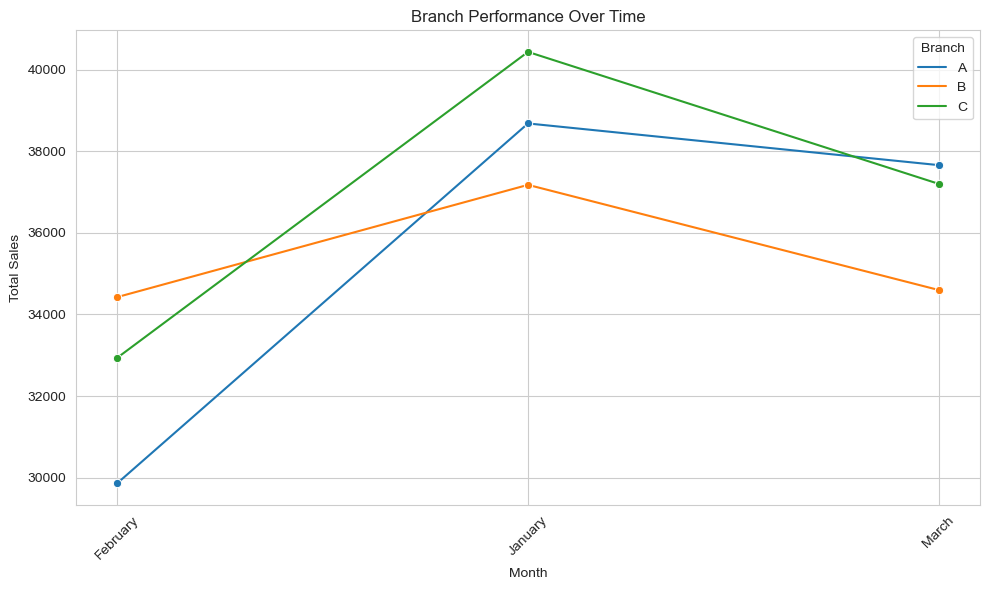

In [65]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")


sns.lineplot(data=branch_month_sales, x='Month', y='Total', hue='Branch', marker='o')

plt.title('Branch Performance Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.legend(title='Branch')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


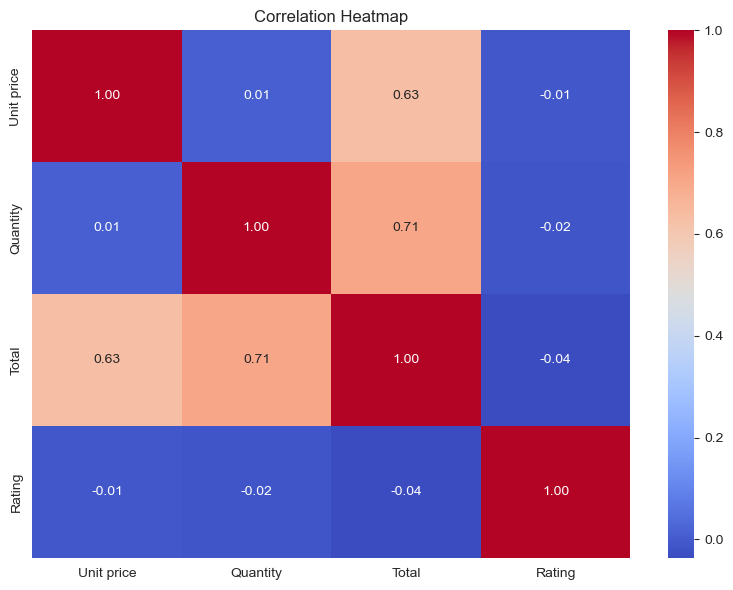

In [66]:


# Step 1: Select the numerical columns
num_cols = ['Unit price', 'Quantity', 'Total', 'Rating']
data = df[num_cols]

# Step 2: Calculate the correlation matrix
corr_matrix = data.corr()

# Step 3: Plot the heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


In [67]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating', 'Month', 'Day', 'DayOfWeek'],
      dtype='object')

In [69]:
payment_methods= df.groupby('Payment')['Total'].sum().sort_values(ascending=False)
print(payment_methods)

Payment
Cash           112206.570
Ewallet        109993.107
Credit card    100767.072
Name: Total, dtype: float64


In [71]:
branch_prod_sales=df.groupby(['Branch','Product line'])['Total'].sum().sort_values(ascending=False)
print(branch_prod_sales)

Branch  Product line          
C       Food and beverages        23766.8550
A       Home and lifestyle        22417.1955
C       Fashion accessories       21560.0700
B       Sports and travel         19988.1990
        Health and beauty         19980.6600
A       Sports and travel         19372.6995
C       Electronic accessories    18968.9745
A       Electronic accessories    18317.1135
B       Home and lifestyle        17549.1645
A       Food and beverages        17163.1005
B       Electronic accessories    17051.4435
C       Health and beauty         16615.3260
B       Fashion accessories       16413.3165
A       Fashion accessories       16332.5085
C       Sports and travel         15761.9280
B       Food and beverages        15214.8885
C       Home and lifestyle        13895.5530
A       Health and beauty         12597.7530
Name: Total, dtype: float64


In [74]:
df['Hour'] = df['Time'].dt.hour

In [76]:
hourly_sales = df.groupby('Hour')['Total'].sum()
print(hourly_sales)

Hour
10    31421.4810
11    30377.3295
12    26065.8825
13    34723.2270
14    30828.3990
15    31179.5085
16    25226.3235
17    24445.2180
18    26030.3400
19    39699.5130
20    22969.5270
Name: Total, dtype: float64


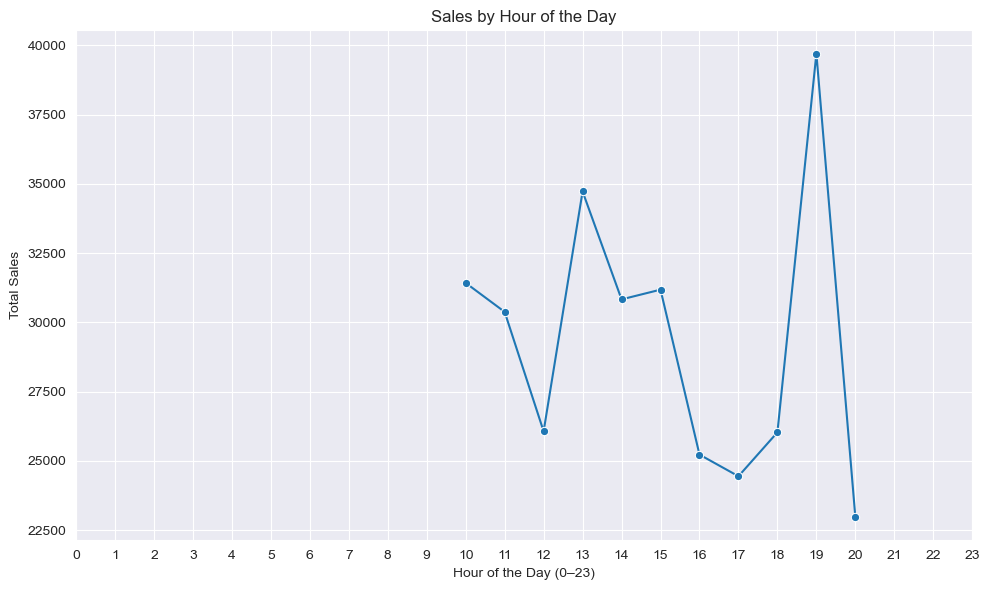

In [77]:
plt.figure(figsize=(10,6))
sns.set_style("darkgrid")

sns.lineplot(x=hourly_sales.index, y=hourly_sales.values, marker='o')

plt.title('Sales by Hour of the Day')
plt.xlabel('Hour of the Day (0–23)')
plt.ylabel('Total Sales')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()
